# Import thư viện

In [ ]:
from vnstock import *
import pandas as pd
import time
import matplotlib.pyplot as plt
import yfinance as yf

# Crawl data

In [68]:
stock = Vnstock().stock(symbol='CMV', source='VCI')

In [77]:
# Lấy dữ liệu VN-Index qua vnstock
vnindex = stock.quote.history(symbol='VNINDEX', start="2014-01-01", end="2024-12-31", interval='1D')
vnindex.to_csv('VNINDEX.csv', index=False)

In [253]:
vnindex = pd.read_csv('VNINDEX.csv')
vnindex['time'] = pd.to_datetime(vnindex['time'])

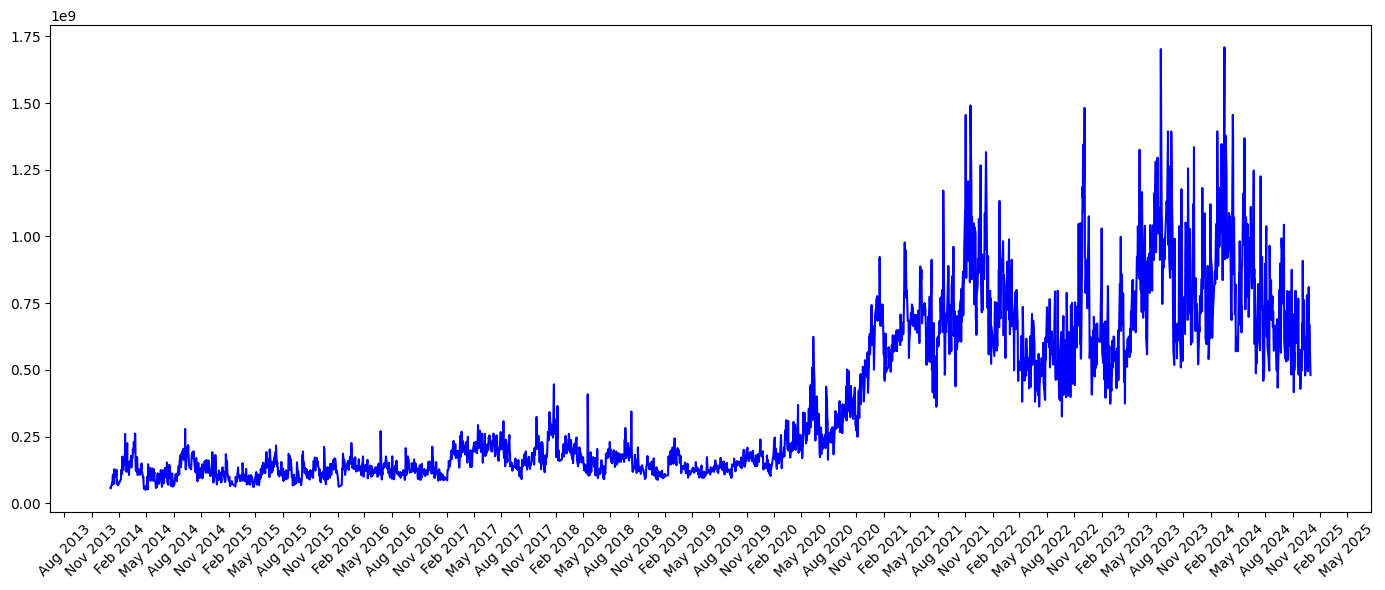

In [254]:
from matplotlib import dates
plt.figure(figsize=(14, 6))  # Tăng size để trục x không bị chật
plt.plot(vnindex['time'], vnindex['volume'], color='blue')
plt.gca().xaxis.set_major_locator(dates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Các chỉ số tương ứng cho 10 sàn chứng khoán lớn nhất thế giới
stock_index_dict = {
    "^DJI": "Dow Jones Industrial Average (Mỹ - NYSE)",
    "000001.SS": "SSE Composite Index (Trung Quốc - Shanghai Stock Exchange)",
    "^FTSE": "FTSE 100 (Anh - London Stock Exchange)",
    "^GSPTSE": "S&P/TSX Composite Index (Canada - TSX)",
    "^AXJO": "ASX 200 (Úc - Australian Securities Exchange)",
    "^BSESN": "BSE SENSEX (Ấn Độ - Bombay Stock Exchange)",
    "^BVSP": "Ibovespa Index (Brazil - B3 Exchange)",
    "^KS11": "KOSPI Index (Hàn Quốc - KRX)",
    "TA35.TA": "TA-35 Index (Israel - TASE)",
    "^J203.JO": "FTSE/JSE Top 40 Index (Nam Phi - Johannesburg Stock Exchange)"
}

# Các chỉ số tương ứng cho 10 sàn chứng khoán lớn nhất thế giới
stock_index_dict2 = {
    "^IXIC": "NASDAQ Composite (Mỹ - NASDAQ)",
    "^HSI": "Hang Seng Index (Hồng Kông - HKEX)",
    "^N100": "Euronext 100 Index (Châu Âu lục địa - Euronext)",
    "^MXX": "IPC Index (Mexico - Bolsa Mexicana de Valores)",
    "^STI": "Straits Times Index (Singapore - SGX)",
    "^N225": "Nikkei 225 (Nhật Bản - JPX)",
    "^SSMI": "Swiss Market Index (Thụy Sĩ - SIX Exchange)",
    "FADGI.AD": "FTSE ADX General Index (UAE - Abu Dhabi Securities Exchange)",
    "^TASI.SR": "Tadawul All Share Index (Saudi Arabia - Saudi Stock Exchange)",
    "^TWII": "TAIEX Index (Đài Loan - Taiwan Stock Exchange)",
    "^NSEI": "NIFTY 50 (Ấn Độ - National Stock Exchange)"
}

In [215]:
# Tải dữ liệu các index thế giới
world_index = pd.DataFrame()

right_column_names = ['close', 'high', 'low', 'open', 'volume']

names = []
for symbol, name in stock_index_dict.items():
    try:
        data = yf.download(symbol, start="2014-01-01", end="2024-12-31")
        data.columns = right_column_names
        right_symbol = symbol.replace('^', '')
        data['symbol'] = right_symbol
        data['name'] = name
        world_index = pd.concat([world_index, data])
    except ValueError as e:
        print(f"Error for symbol {symbol}: {e}")
    except Exception as e:
        print(f"Failed to fetch {name}: {e}")
    time.sleep(1)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [216]:
world_index = world_index.reset_index().rename(columns={'Date':'time'})

In [217]:
world_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    27316 non-null  datetime64[ns]
 1   close   27316 non-null  float64       
 2   high    27316 non-null  float64       
 3   low     27316 non-null  float64       
 4   open    27316 non-null  float64       
 5   volume  27316 non-null  int64         
 6   symbol  27316 non-null  object        
 7   name    27316 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 1.7+ MB


In [255]:
vnindex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2743 entries, 0 to 2742
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    2743 non-null   datetime64[ns]
 1   open    2743 non-null   float64       
 2   high    2743 non-null   float64       
 3   low     2743 non-null   float64       
 4   close   2743 non-null   float64       
 5   volume  2743 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 128.7 KB


In [219]:
world_index = world_index[['time', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'name']]

In [221]:
world_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    27316 non-null  datetime64[ns]
 1   open    27316 non-null  float64       
 2   high    27316 non-null  float64       
 3   low     27316 non-null  float64       
 4   close   27316 non-null  float64       
 5   volume  27316 non-null  int64         
 6   symbol  27316 non-null  object        
 7   name    27316 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 1.7+ MB


In [222]:
world_index.to_csv('World_Index.csv', index=False)

# Phân tích sự tăng trưởng Index của VNINDEX và 10 sàn thế giới

**Các mã chứng khoán thế giới:**    
- DJI:   Mỹ - NYSE
- 000001.SS:   Trung Quốc - Shanghai 
- FTSE:   Anh - London 
- GSPTSE:   Canada
- AXJO:   Úc 
- BSESN:    Ấn Độ - Bombay 
- BVSP:   Brazil  
- KS11:   Hàn Quốc 
- TA35.TA:    Israel 
- J203.JO:    Nam Phi - Johannesburg 

In [256]:
def growth_index_per_day(close):
    if close.empty:
        return pd.Series()
    return (close - close.iloc[0]) * 100 / close.iloc[0]    

In [265]:
import matplotlib.dates as mdates
def show_all_indexes_comparison():
    plt.figure(figsize=(20, 10))

    # Lặp qua từng chỉ số
    for symbol in world_index['symbol'].unique():
        df_stock = world_index[world_index['symbol'] == symbol].copy()
        df_stock = df_stock.sort_values('time')  # đảm bảo đúng thời gian
        name = df_stock['name'].unique()
        
        # Vẽ đường tăng trưởng
        plt.plot(
            df_stock['time'],
            growth_index_per_day(df_stock['close']),
            label=name
        )

    # Thêm VNINDEX
    vnindex_sorted = vnindex.sort_values('time')
    plt.plot(
        vnindex_sorted['time'],
        growth_index_per_day(vnindex_sorted['close']),
        label='VNINDEX', color='red', linewidth=2.5
    )

    # Định dạng trục x
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)

    plt.grid(True)
    plt.title("So sánh tăng trưởng các chỉ số thế giới với VN-INDEX (10 năm)", fontsize=18)
    plt.xlabel("Thời gian")
    plt.ylabel("Tăng trưởng % so với thời điểm đầu")
    plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout()
    plt.show()

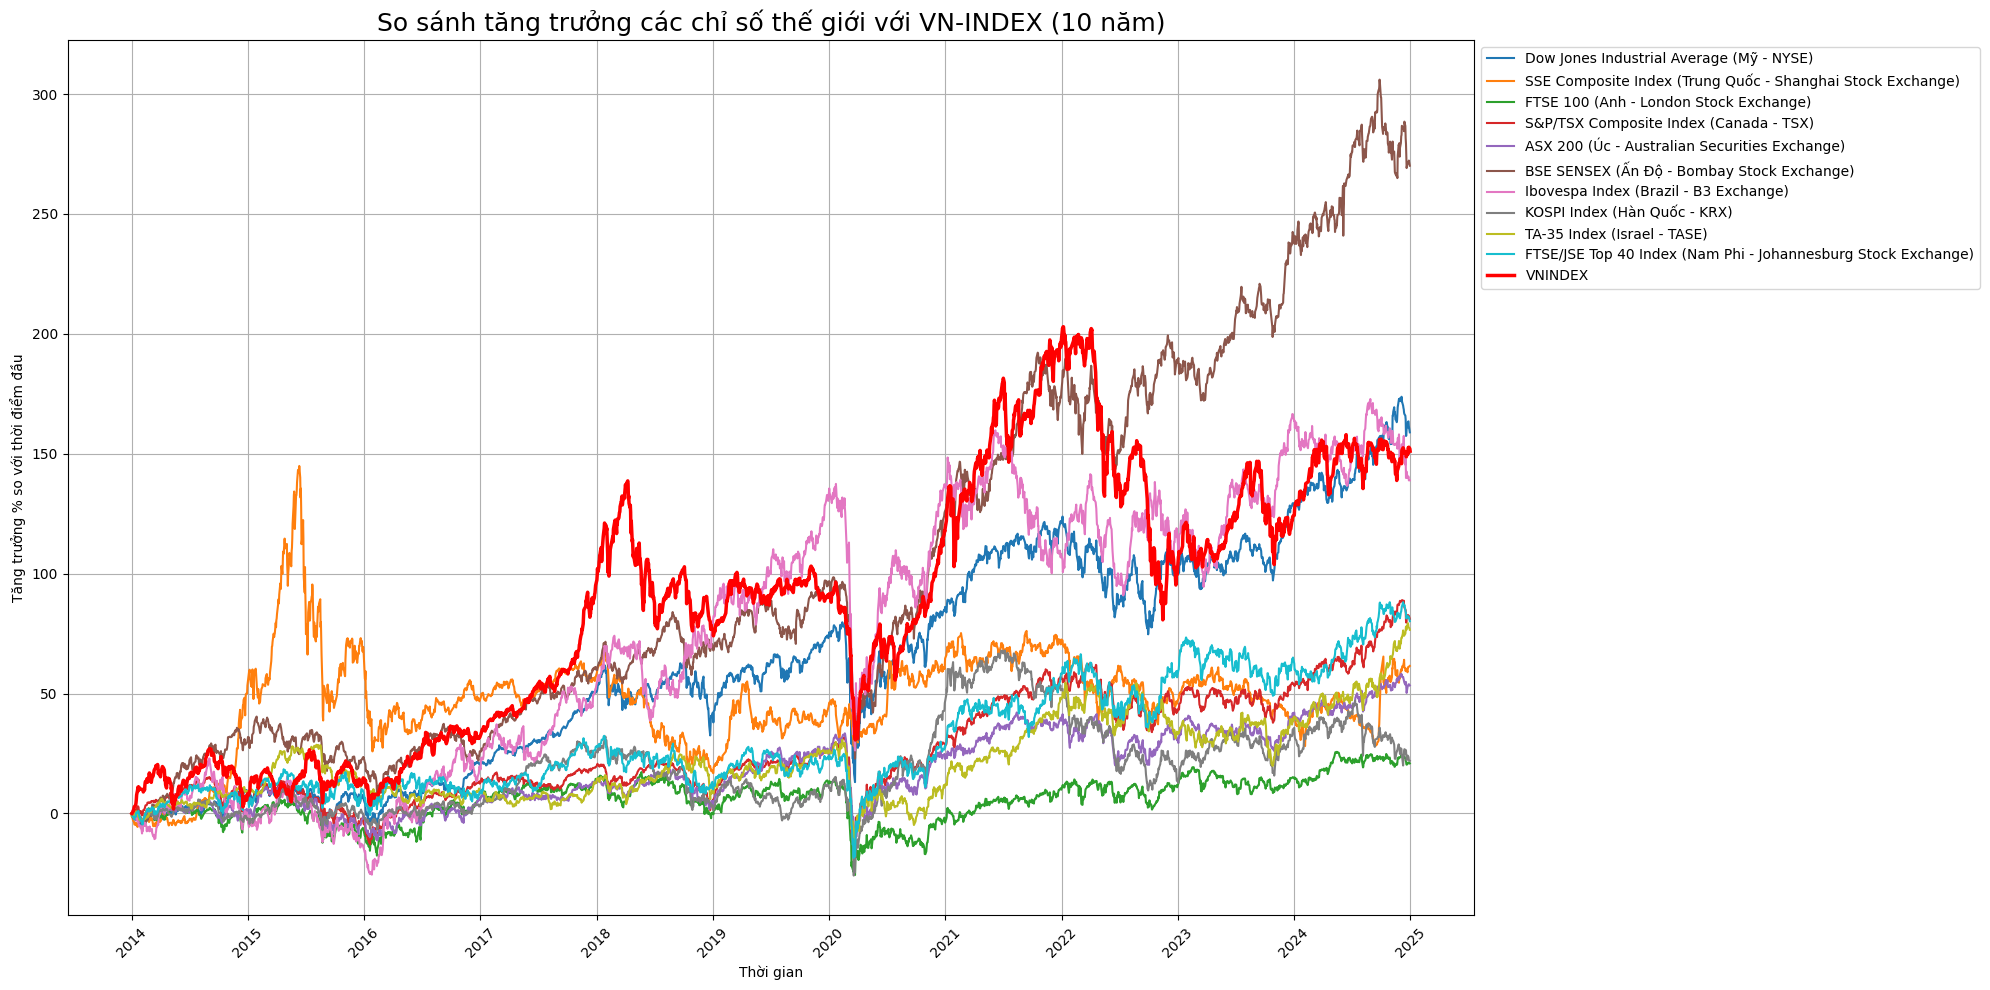

In [266]:
show_all_indexes_comparison()

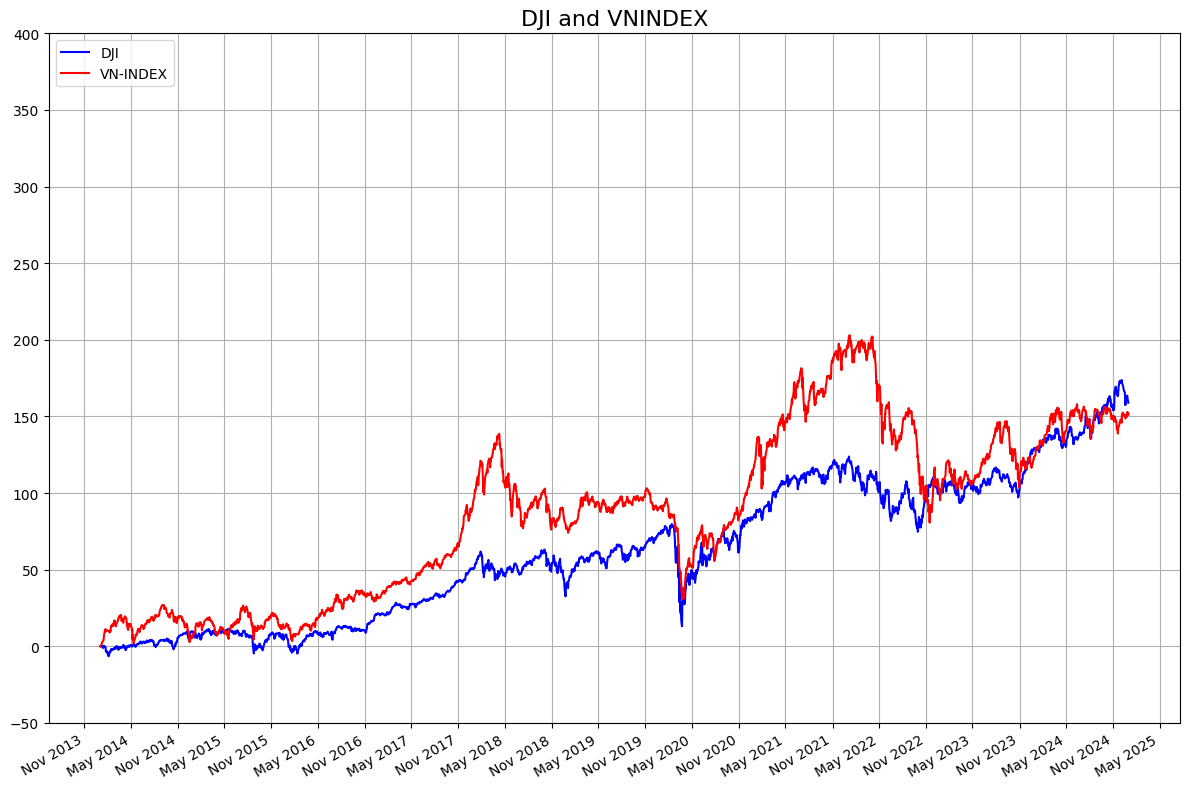

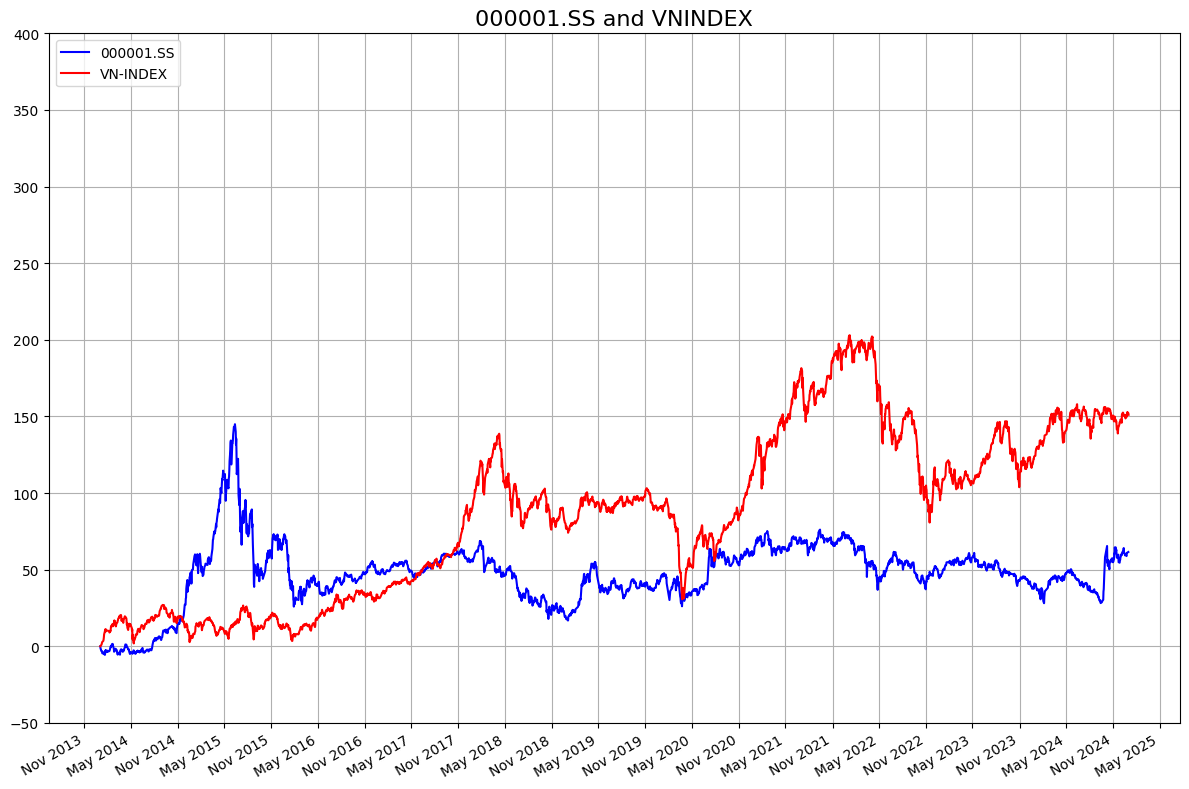

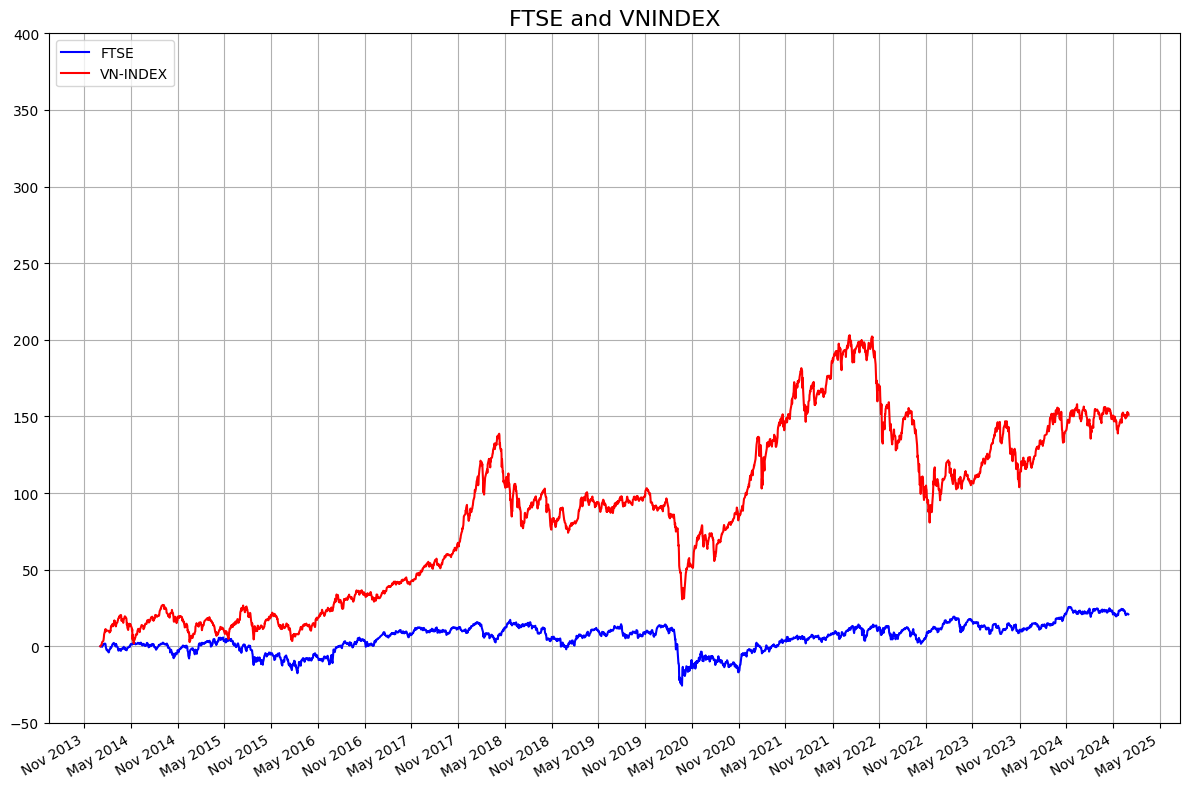

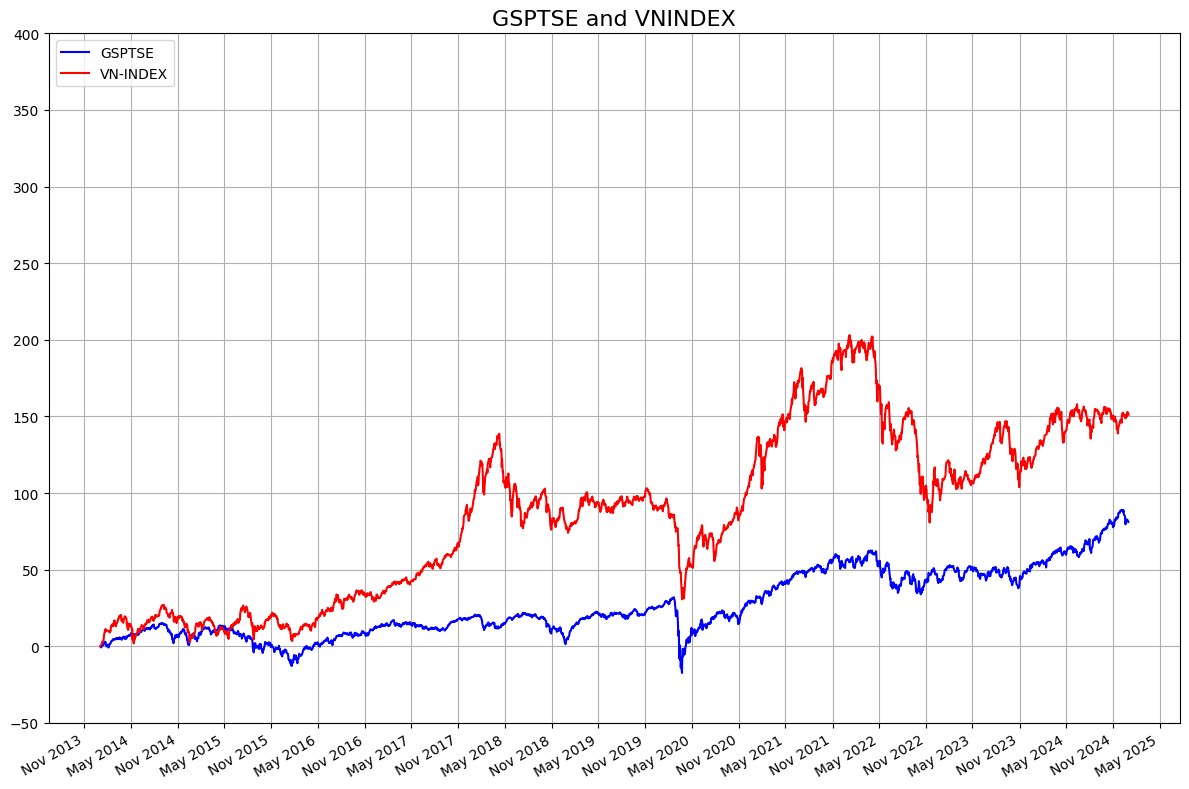

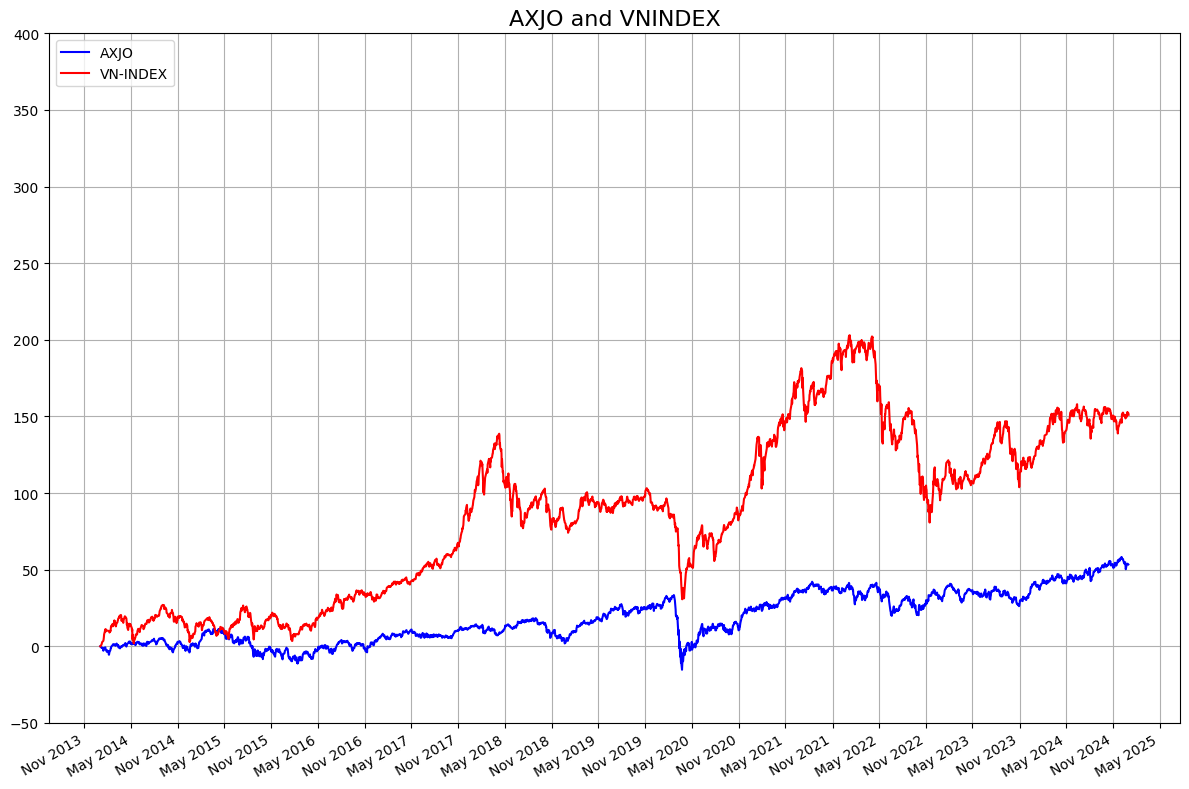

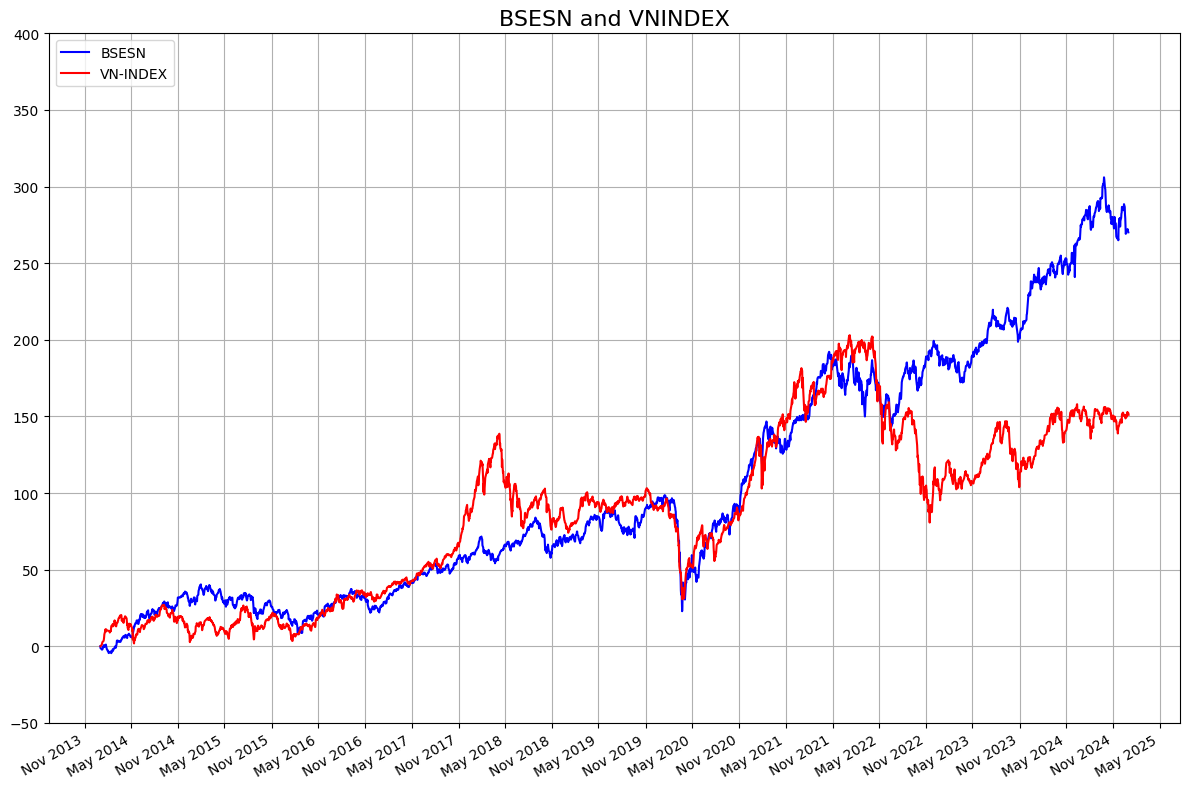

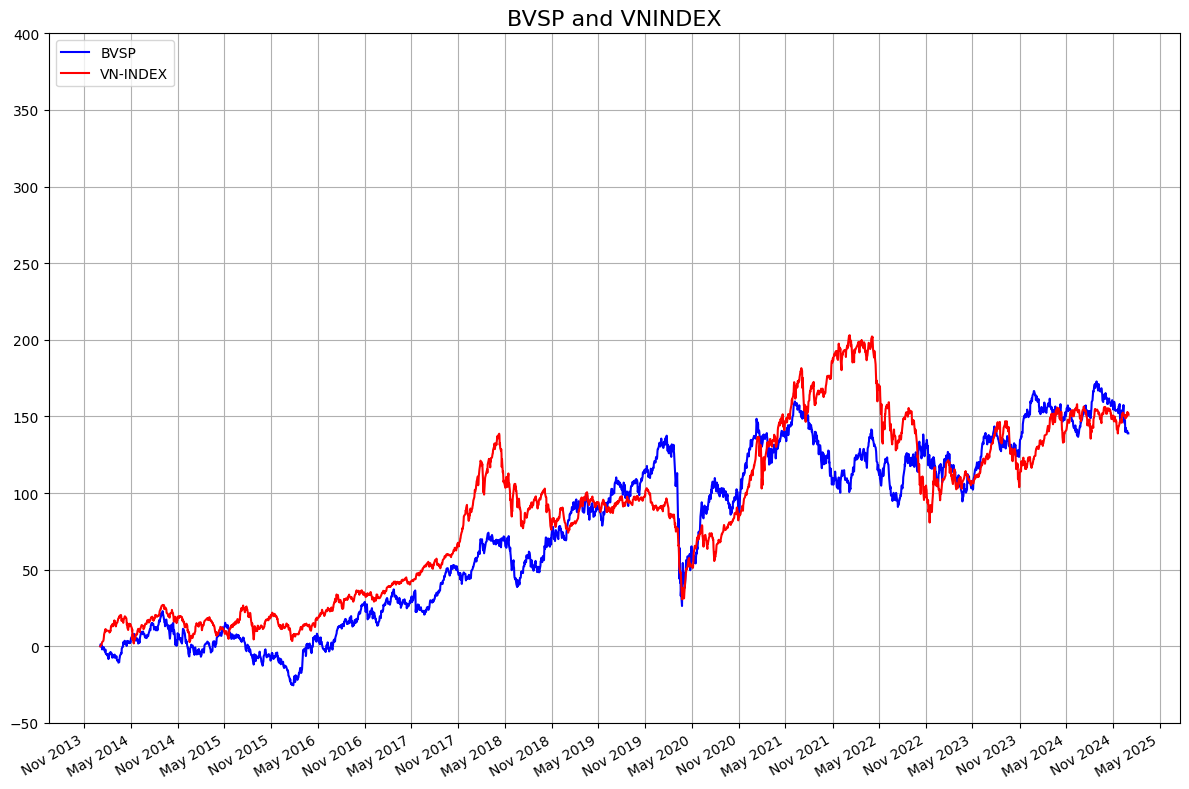

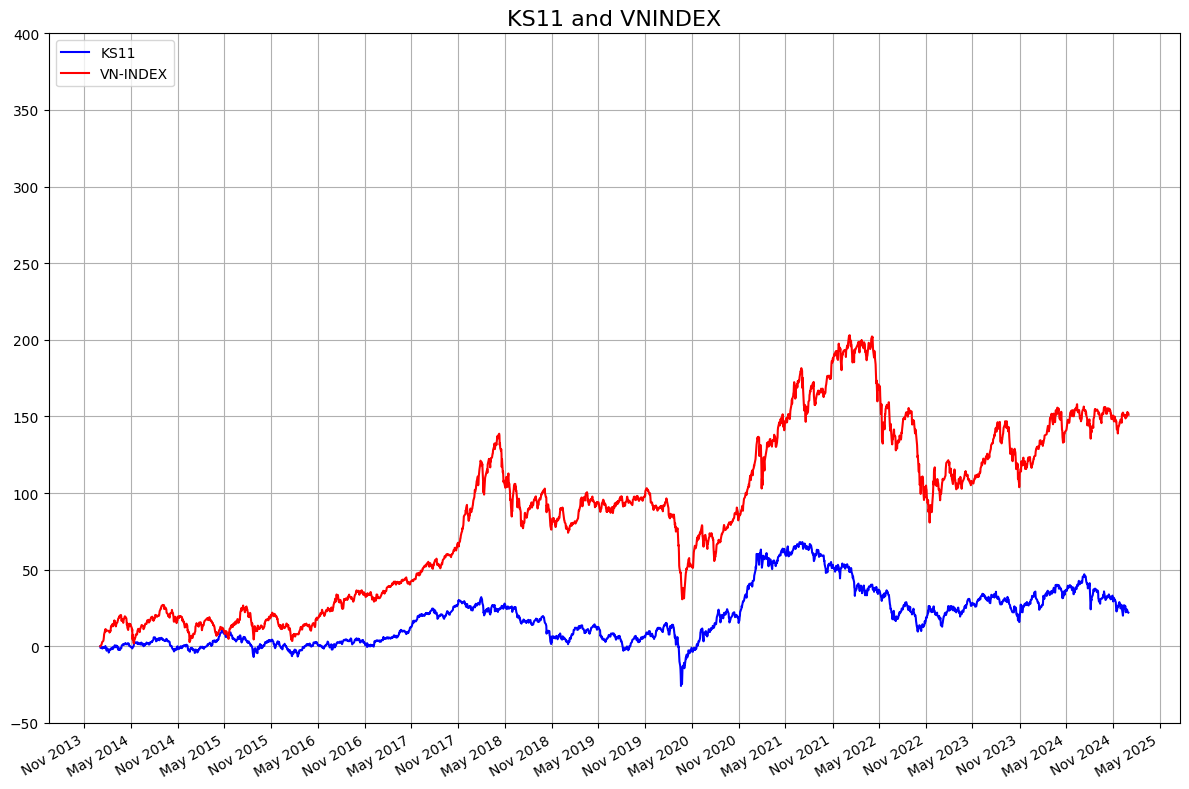

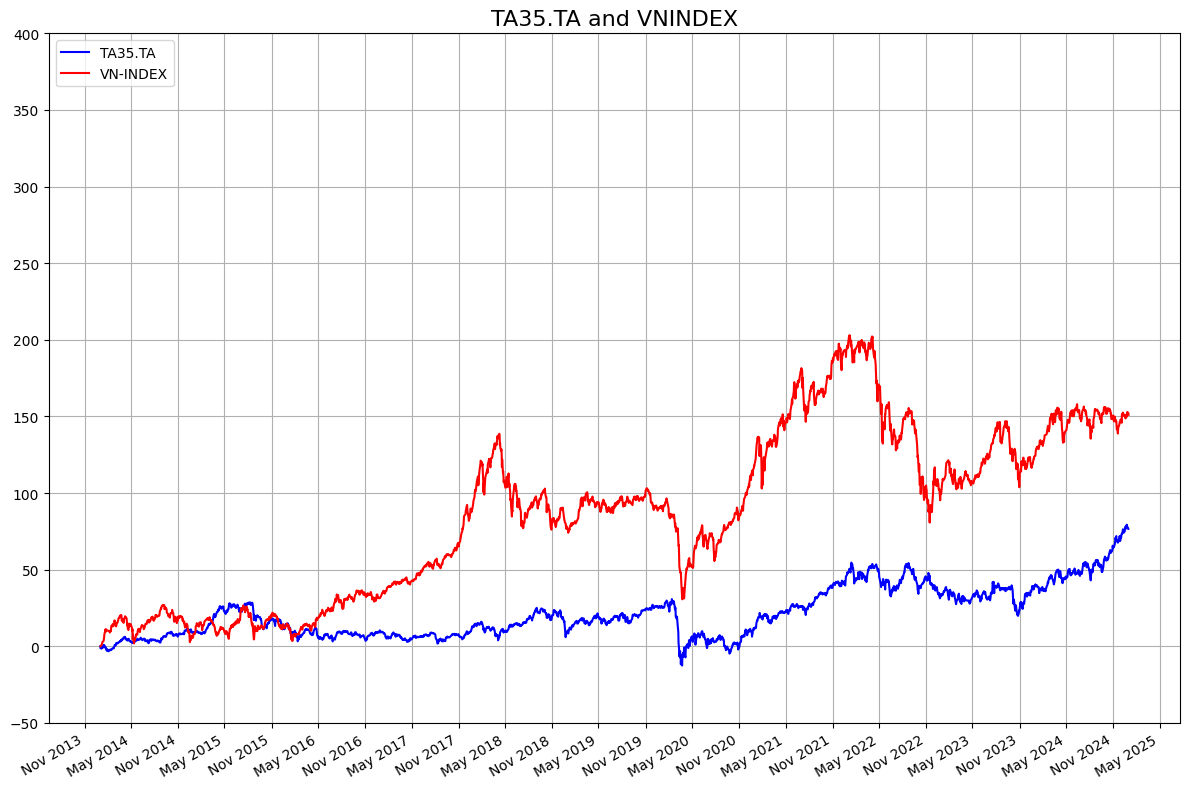

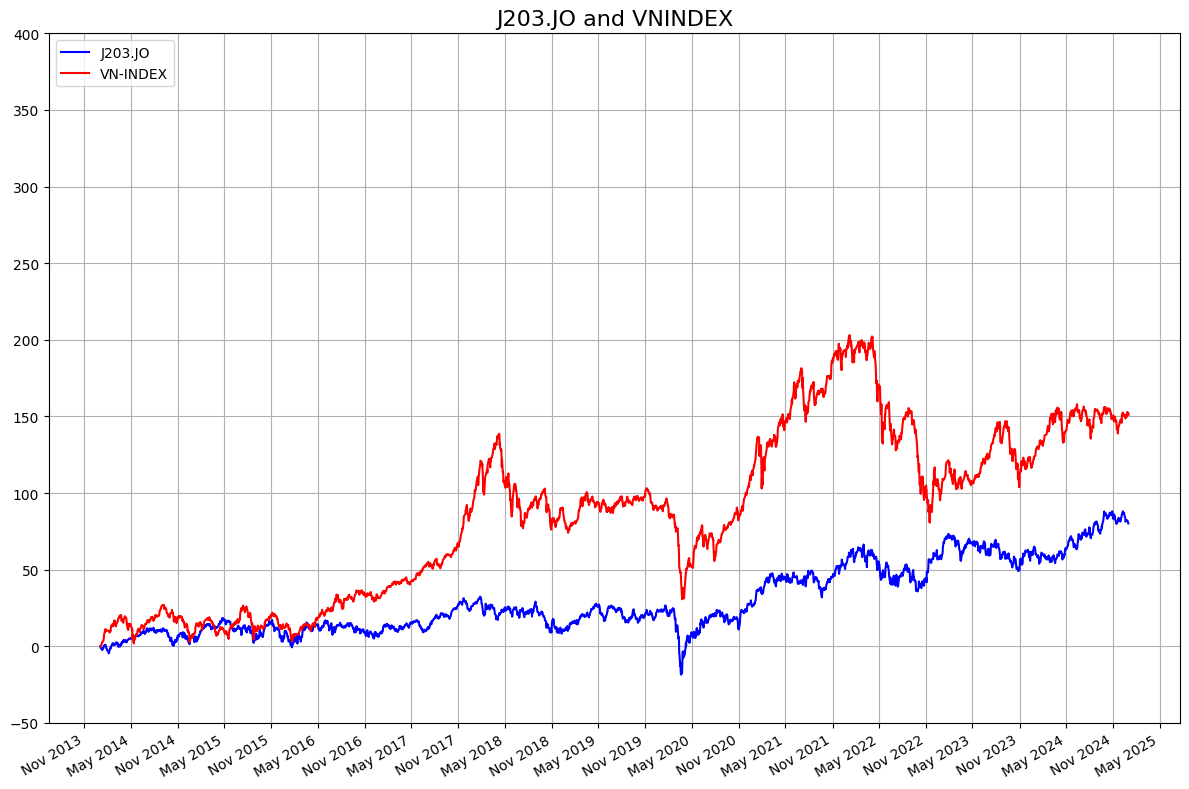

In [272]:
from matplotlib import dates

def show_plt(symbol):
  time_stock = world_index[world_index['symbol'] == symbol]['time']
  value_stock = world_index[world_index['symbol'] == symbol]['close']

  time_vnindex = vnindex['time']
  value_vnindex = vnindex['close']

  plt.figure(figsize=(12, 8))
  plt.plot(time_stock, growth_index_per_day(value_stock), color='blue', label=f"{symbol}")
  plt.plot(time_vnindex, growth_index_per_day(value_vnindex), color='red', label="VN-INDEX")

  plt.gca().xaxis.set_major_locator(dates.MonthLocator(interval=6))
  plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%b %Y'))
  plt.gcf().autofmt_xdate()

  plt.grid(True)
  plt.legend(loc='upper left')  # Đảm bảo legend hiển thị
  # Cố định scale trục tung
  plt.ylim(-50, 400)  # Điều chỉnh tùy theo độ biến động bạn muốn theo dõi

  plt.title(f"{symbol} and VNINDEX", fontsize=16)

  plt.tight_layout()
  plt.show()
  
for symbol in world_index['symbol'].unique():
  show_plt(symbol)

In [226]:
def growth_index_10_years(df):
    close_last = df.loc[df['time'].idxmax(), 'close']
    close_first = df.loc[df['time'].idxmin(), 'close']
    growth_value = (close_last - close_first) * 100 / close_first
    return growth_value

In [227]:
vnindex_item = {}
vnindex_item['symbol'] = 'VNINDEX'
vnindex_item['value'] = growth_index_10_years(vnindex)

world_symbols = []
for symbol in world_index['symbol'].unique():
    item = {}
    item['symbol'] = symbol
    df_symbol = world_index[(world_index['symbol'] == symbol)]
    item['value'] = growth_index_10_years(df_symbol)
    world_symbols.append(item)

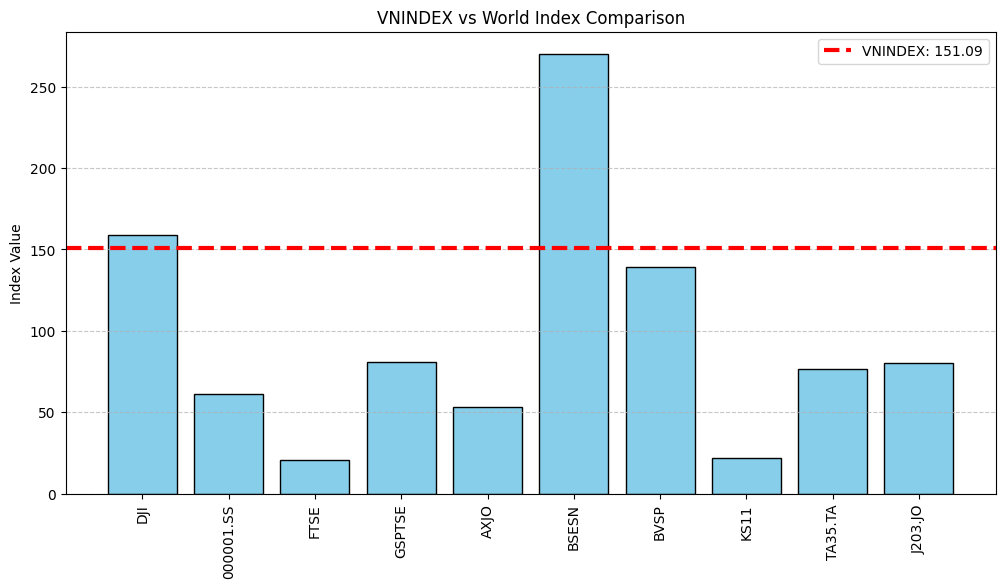

In [236]:
vnindex_value = vnindex_item['value']

symbols = [symbol_stock['symbol'] for symbol_stock in world_symbols]
values = [symbol_stock['value'] for symbol_stock in world_symbols]

plt.figure(figsize=(12, 6))
plt.bar(symbols, values, color='skyblue', edgecolor='black')

plt.axhline(y=vnindex_value, color="red", linestyle="--", linewidth=3, label=f"VNINDEX: {vnindex_value:.2f}")

plt.xticks(rotation=90)
plt.ylabel("Index Value")
plt.title("VNINDEX vs World Index Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Phân tích chỉ số tăng Index của VN30 với 10 sàn thế giới

**10 sàn chứng khoán lớn của thế giới:**
- IXIC: Mỹ - NASDAQ
- HSI: Hồng Kông - HKEX
- N100: Châu Âu lục địa - Euronext
- MXX: Mexico
- STI": Singapore - SGX
- N225": Nhật Bản - JPX
- SSMI: Thụy Sĩ - SIX
- **FADGI.AD: UAE** -> không tồn tại 
- TASI.SR: Saudi Arabia
- TWII: Đài Loan,
- NSEI: Ấn Độ

In [3]:
vn30 = pd.read_csv('VN30.csv')
world_index2 = pd.read_csv('World_Index_2.csv')

In [11]:
vn30['time'] = pd.to_datetime(vn30['time'])
vn30.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1839 entries, 0 to 1838
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    1839 non-null   datetime64[ns]
 1   open    1839 non-null   float64       
 2   high    1839 non-null   float64       
 3   low     1839 non-null   float64       
 4   close   1839 non-null   float64       
 5   volume  1839 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 86.3 KB


In [12]:
world_index2['time'] = pd.to_datetime(world_index2['time'])
world_index2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27094 entries, 0 to 27093
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    27094 non-null  datetime64[ns]
 1   open    27094 non-null  float64       
 2   high    27094 non-null  float64       
 3   low     27094 non-null  float64       
 4   close   27094 non-null  float64       
 5   volume  27094 non-null  int64         
 6   symbol  27094 non-null  object        
 7   name    27094 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 1.7+ MB


In [13]:
def growth_index_per_day(close):
    if close.empty:
        return pd.Series()
    return (close - close.iloc[0]) * 100 / close.iloc[0]    

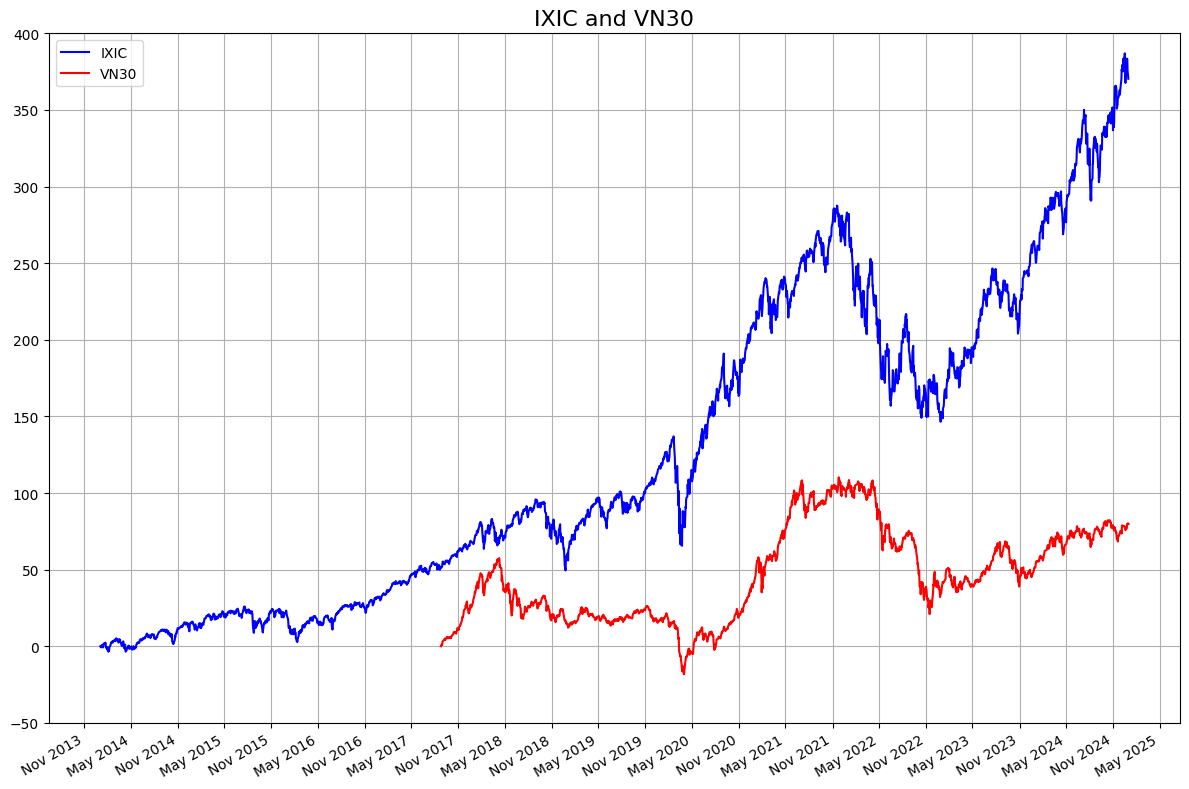

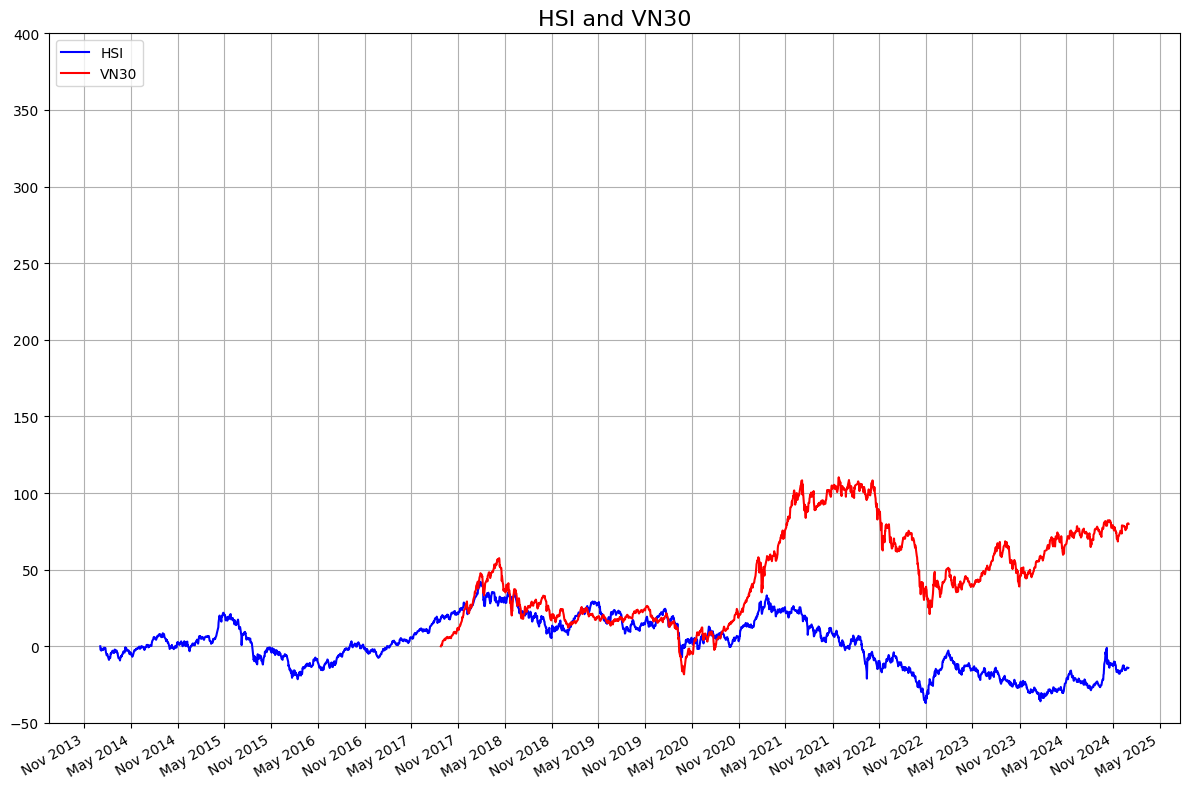

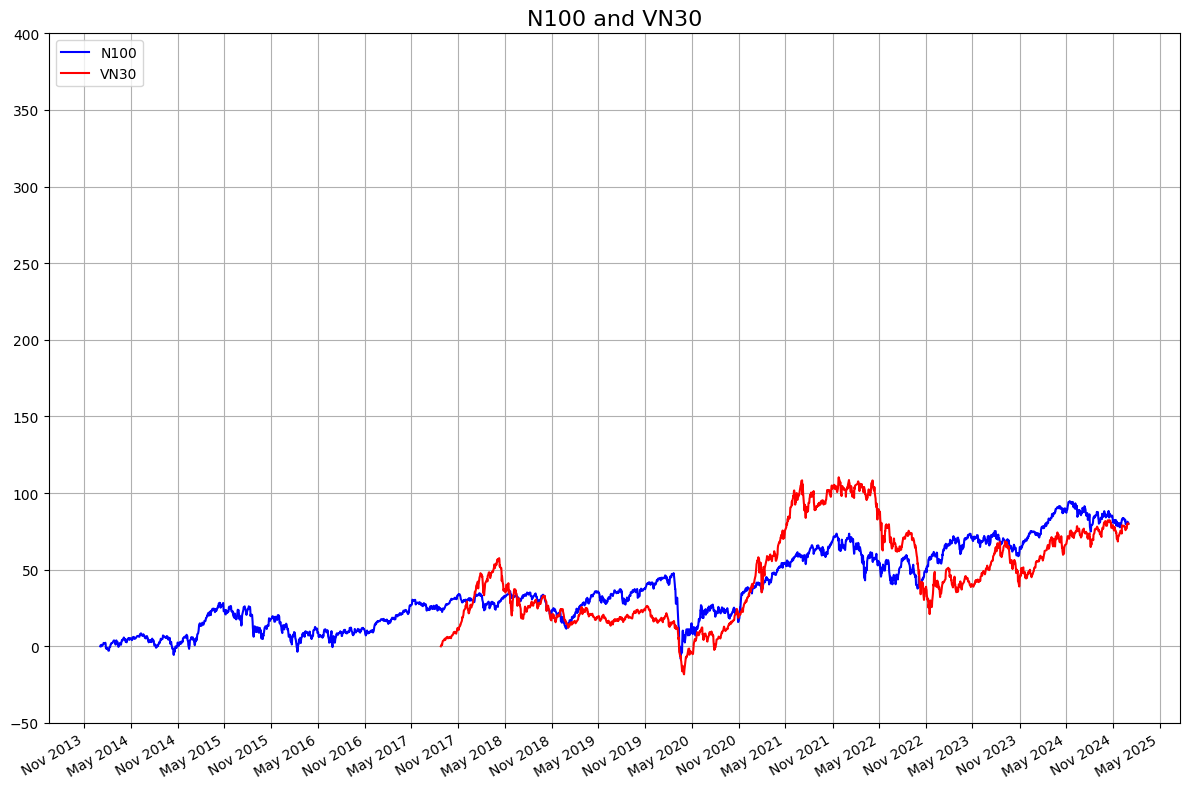

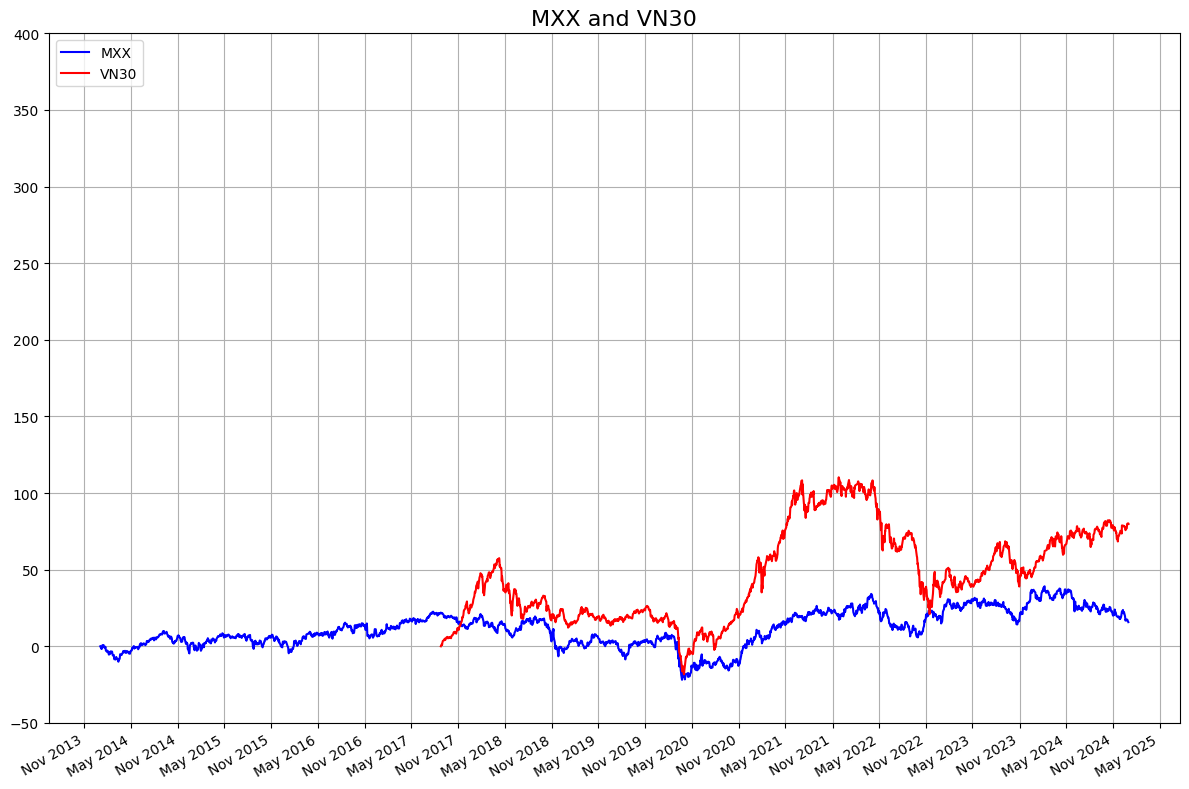

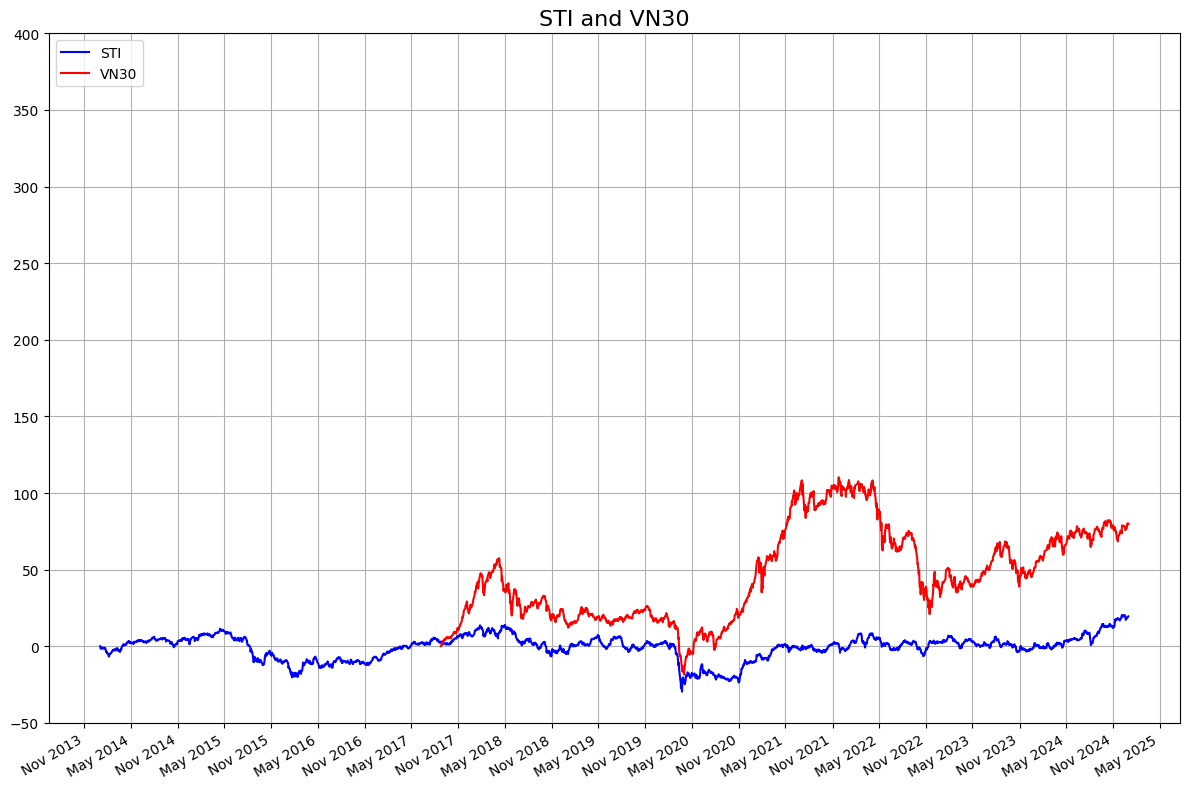

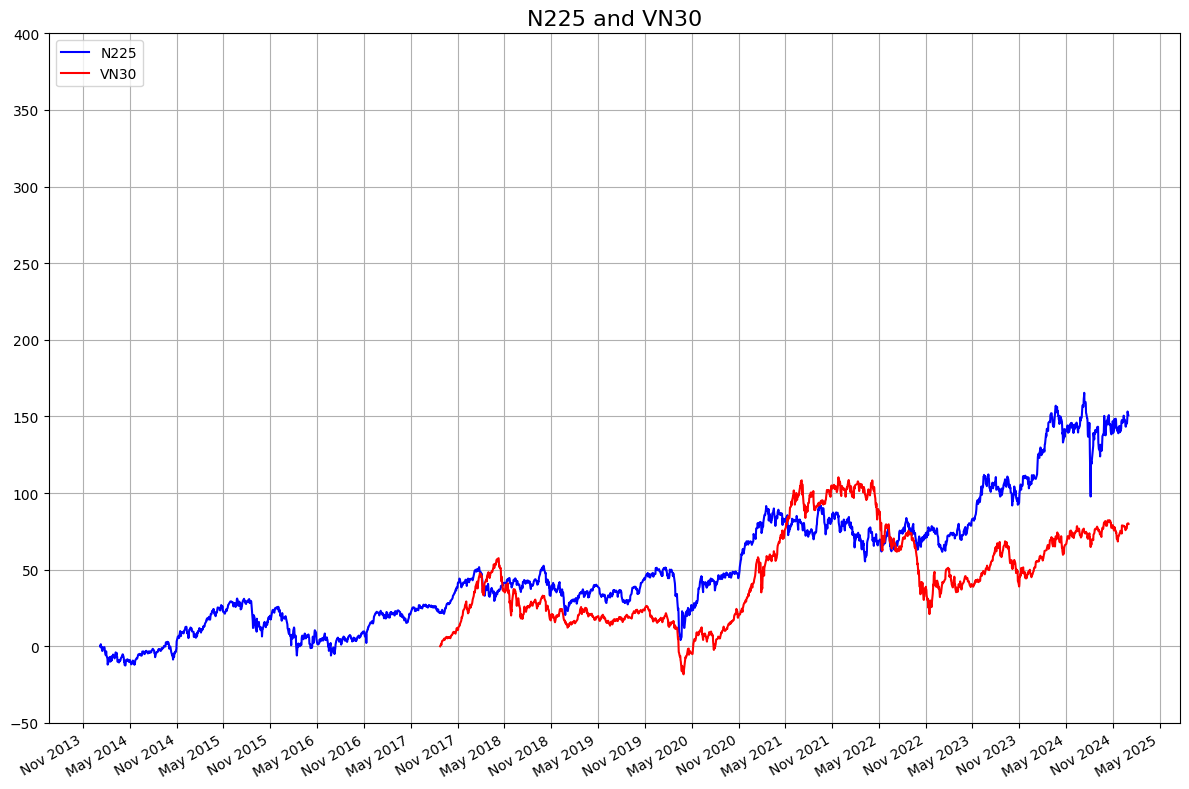

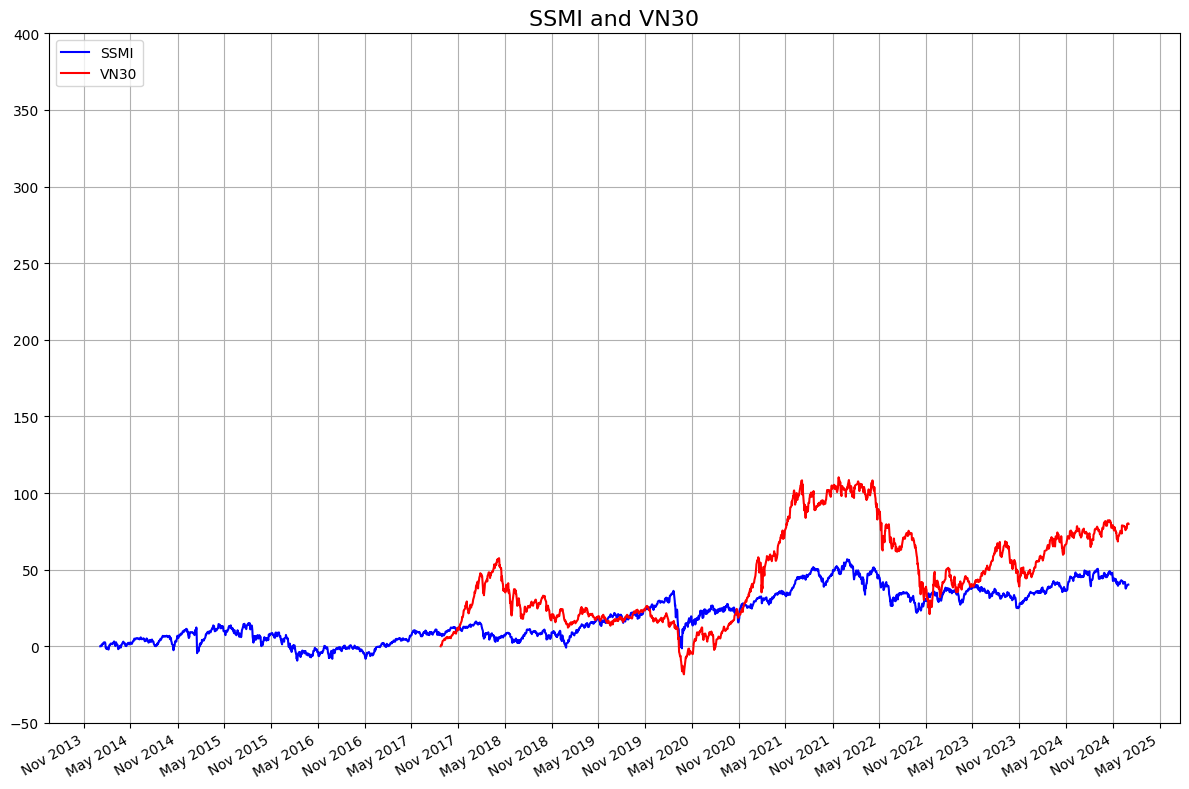

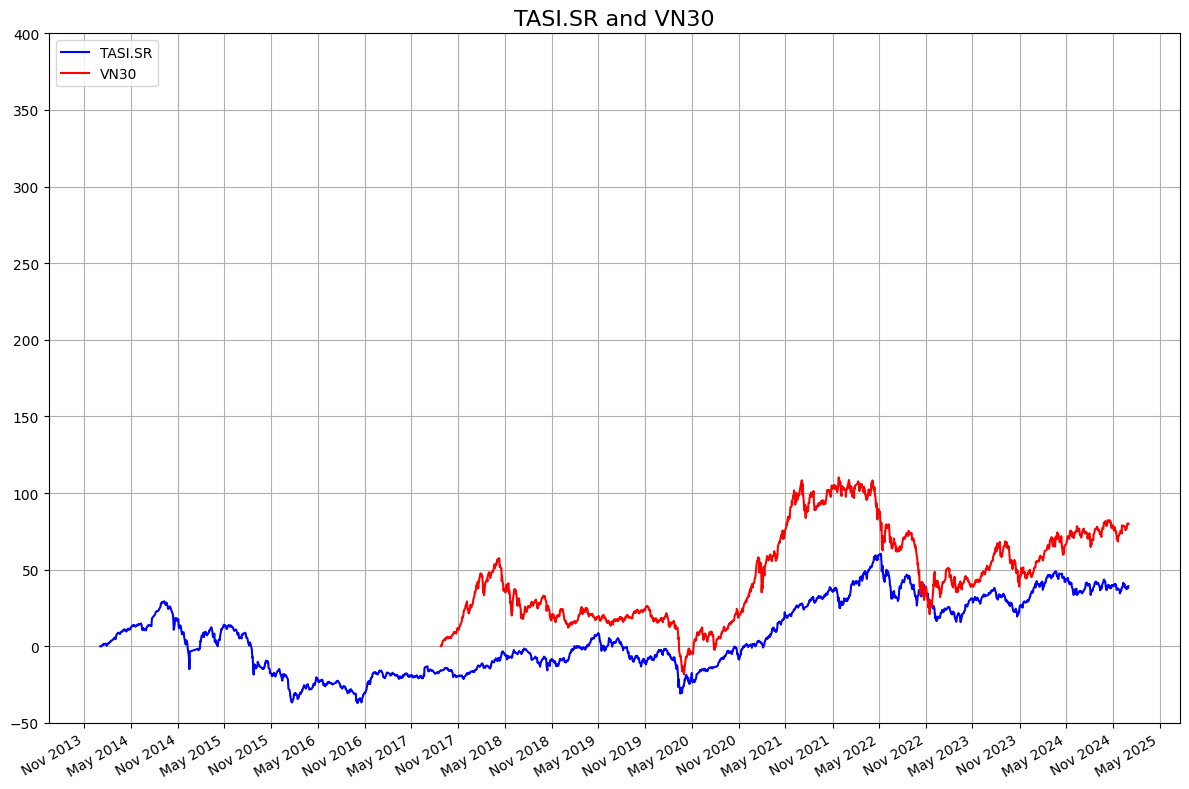

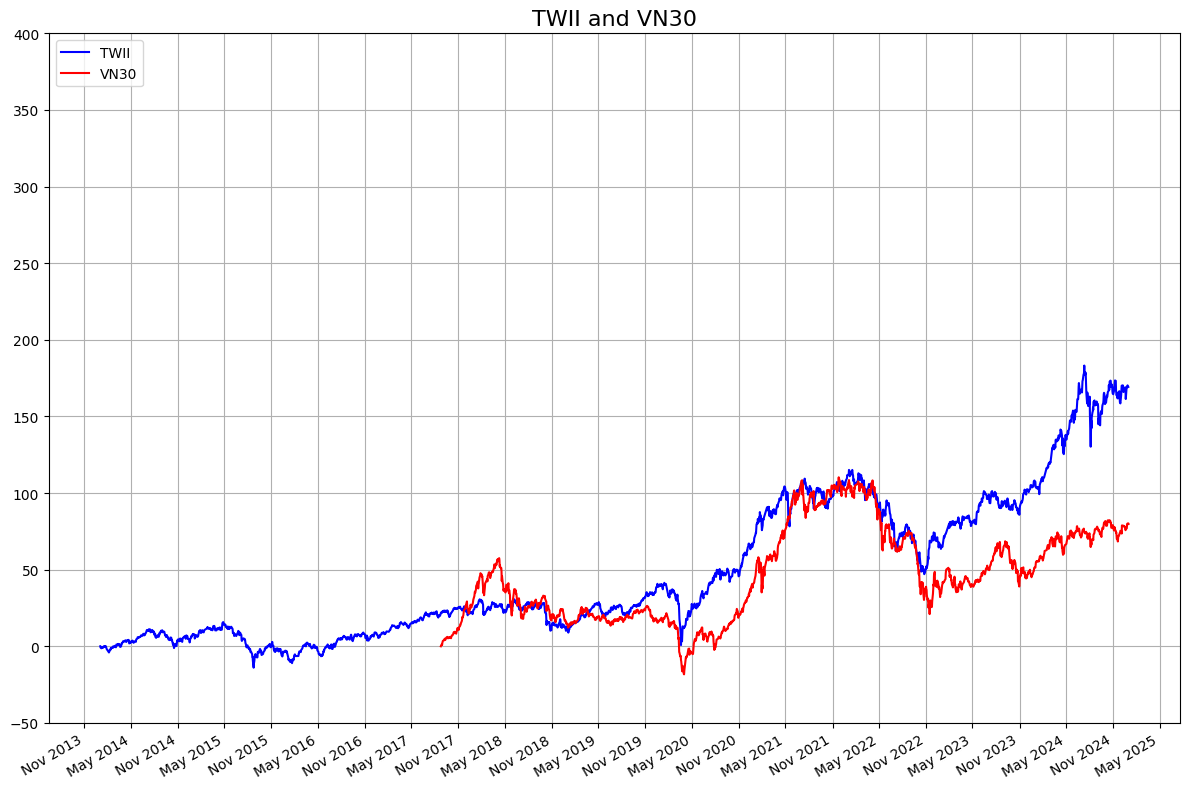

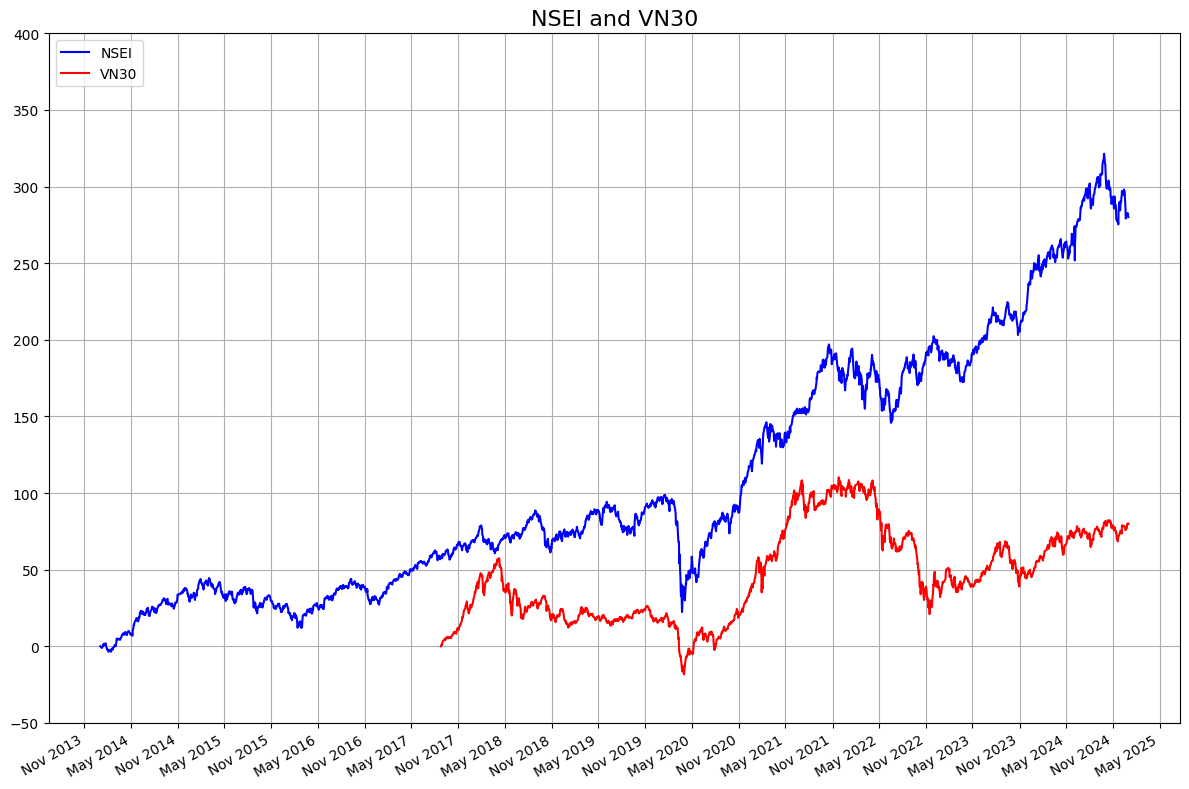

In [15]:
from matplotlib import dates

def show_plt(symbol):
  time_stock = world_index2[world_index2['symbol'] == symbol]['time']
  value_stock = world_index2[world_index2['symbol'] == symbol]['close']

  time_vn30 = vn30['time']
  value_vn30 = vn30['close']

  plt.figure(figsize=(12, 8))
  plt.plot(time_stock, growth_index_per_day(value_stock), color='blue', label=f"{symbol}")
  plt.plot(time_vn30, growth_index_per_day(value_vn30), color='red', label="VN30")

  plt.gca().xaxis.set_major_locator(dates.MonthLocator(interval=6))
  plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%b %Y'))
  plt.gcf().autofmt_xdate()

  plt.grid(True)
  plt.legend(loc='upper left')  # Đảm bảo legend hiển thị
  # Cố định scale trục tung
  plt.ylim(-50, 400)  # Điều chỉnh tùy theo độ biến động bạn muốn theo dõi

  plt.title(f"{symbol} and VN30", fontsize=16)

  plt.tight_layout()
  plt.show()
  
for symbol in world_index2['symbol'].unique():
  show_plt(symbol)

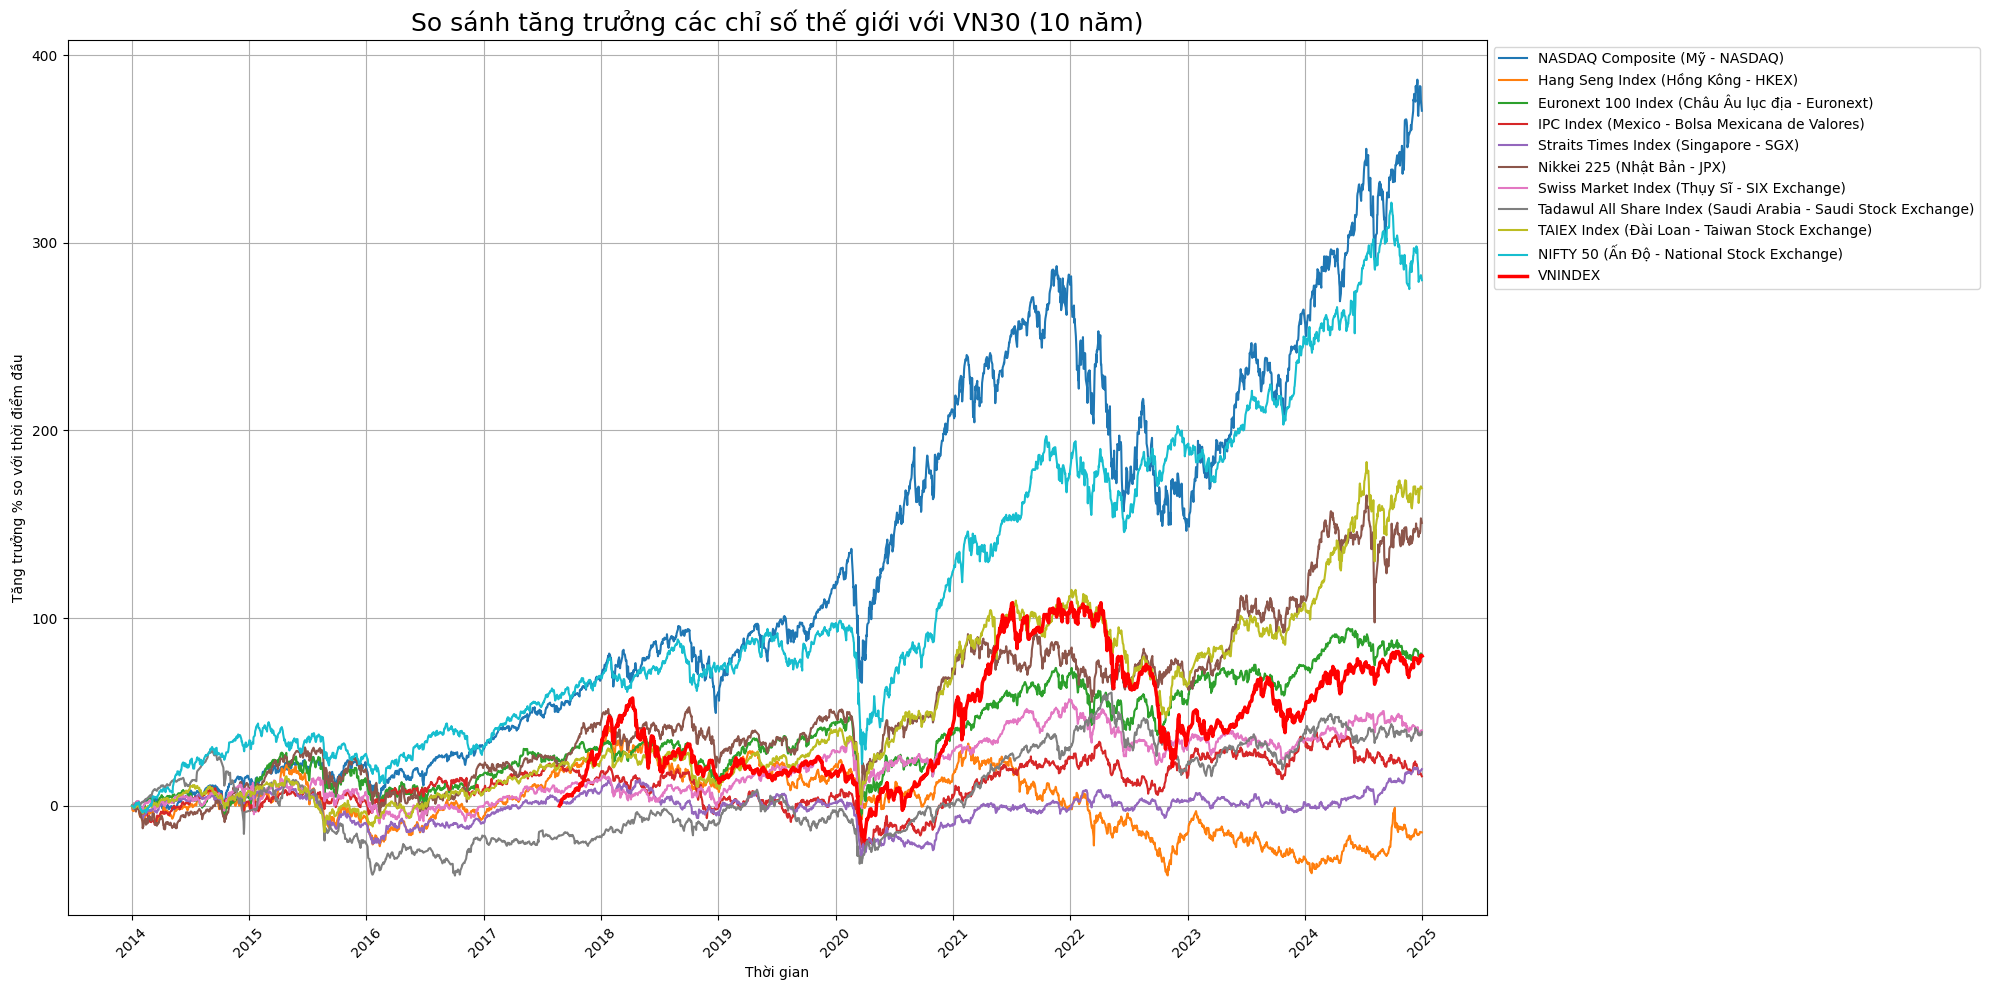

In [24]:
import matplotlib.dates as mdates
def show_all_indexes_comparison():
    plt.figure(figsize=(20, 10))

    # Lặp qua từng chỉ số
    for symbol in world_index2['symbol'].unique():
        df_stock = world_index2[world_index2['symbol'] == symbol].copy()
        df_stock = df_stock.sort_values('time')  # đảm bảo đúng thời gian
        name = df_stock['name'].unique()
        
        # Vẽ đường tăng trưởng
        plt.plot(
            df_stock['time'],
            growth_index_per_day(df_stock['close']),
            label=name
        )

    # Thêm VN30
    vn30_sorted = vn30.sort_values('time')
    plt.plot(
        vn30_sorted['time'],
        growth_index_per_day(vn30_sorted['close']),
        label='VNINDEX', color='red', linewidth=2.5
    )

    # Định dạng trục x
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)

    plt.grid(True)
    plt.title("So sánh tăng trưởng các chỉ số thế giới với VN30 (10 năm)", fontsize=18)
    plt.xlabel("Thời gian")
    plt.ylabel("Tăng trưởng % so với thời điểm đầu")
    plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout()
    plt.show()
    
show_all_indexes_comparison()

In [18]:
def growth_index_10_years(df):
    close_last = df.loc[df['time'].idxmax(), 'close']
    close_first = df.loc[df['time'].idxmin(), 'close']
    growth_value = (close_last - close_first) * 100 / close_first
    return growth_value

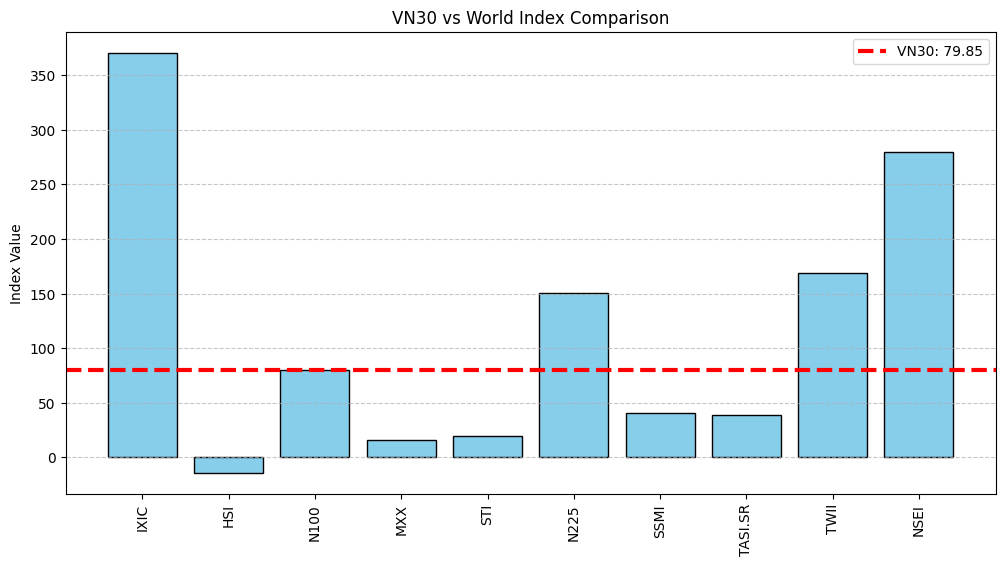

In [21]:
vn30_item = {}
vn30_item['symbol'] = 'VN30'
vn30_item['value'] = growth_index_10_years(vn30)

world_symbols = []
for symbol in world_index2['symbol'].unique():
    item = {}
    item['symbol'] = symbol
    df_symbol = world_index2[(world_index2['symbol'] == symbol)]
    item['value'] = growth_index_10_years(df_symbol)
    world_symbols.append(item)
    
vn30_value = vn30_item['value']
symbols = [symbol_stock['symbol'] for symbol_stock in world_symbols]
values = [symbol_stock['value'] for symbol_stock in world_symbols]

plt.figure(figsize=(12, 6))
plt.bar(symbols, values, color='skyblue', edgecolor='black')
plt.axhline(y=vn30_value, color="red", linestyle="--", linewidth=3, label=f"VN30: {vn30_value:.2f}")
plt.xticks(rotation=90)
plt.ylabel("Index Value")
plt.title("VN30 vs World Index Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()